# ESS 배터리 수명 예측
**회귀 / 초기 100사이클 → 총 `cycle_life`**

초기 100사이클의 ΔQ(V), 용량 변화, 충전 시간과 정책으로 **총 수명**을 예측합니다.
셀 1개가 표본 1개이며, B1에서 모델을 선택하고 B2에서 성능을 평가합니다.

**진행 순서:** Feature 확인 → 정책별 분할 → 모델 비교 → 설정 고정 → hold-out·B2 평가 → 오차 해석

처음 실행할 때는 위에서부터 모든 셀을 실행합니다.

## 1. 실행 준비
같은 폴더의 `battery_features.py`, `battery_modeling.py`와 `requirements.txt`를 사용합니다.
기본 데이터 위치는 `dataset`, 결과는 `results/`입니다. 위치가 다르면 아래 경로나 `ESS_DATA_DIR` 환경변수만 바꿉니다.
설치는 README를 참고합니다. Batch 3는 추가 평가용이며 기본 실행에서는 제외합니다.

In [1]:
from pathlib import Path
import os
import platform
import importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from battery_features import load_feature_table, BATCH_FILES, FEATURE_COLUMNS
from battery_modeling import (
    FEATURE_SETS, prepare_batch1, make_splits, compare_models, choose_model,
    cross_validation_predictions, evaluate_predictions, metrics,
    performance_table, freeze_choice, refit_final_model,
    plot_cv_comparison, plot_predictions, plot_error_analysis,
    error_by_life_band,
)

DATA_DIR = Path(os.environ.get("ESS_DATA_DIR", "dataset"))
OUTPUT_DIR = Path(os.environ.get("ESS_OUTPUT_DIR", "results"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
HOLDOUT_SIZE = 0.20
SIMPLICITY_TOLERANCE_PP = 1.0   # CV 최저 MAPE와 1%p 이내이면 단순한 구성 우선
PAPER_TARGET_MAPE = 9.1         # 논문 참고값; 같은 조건의 재현값은 아님
EVALUATE_BATCH3 = False

pd.set_option("display.max_columns", 16)
pd.set_option("display.float_format", "{:.3f}".format)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})

for batch in ("Batch 1", "Batch 2"):
    path = DATA_DIR / BATCH_FILES[batch]
    if not path.is_file():
        raise FileNotFoundError(f"{batch} 파일이 없습니다: {path.resolve()}")
print(f"Python {platform.python_version()} | Batch 1·2 데이터 파일 확인 완료")
print(" / ".join(f"{name} {importlib.metadata.version(name)}"
                 for name in ("numpy", "pandas", "scikit-learn", "h5py")))

Python 3.11.15 | Batch 1·2 데이터 파일 확인 완료
numpy 2.4.6 / pandas 3.0.6 / scikit-learn 1.9.1 / h5py 3.16.0


## 2. EDA를 바탕으로 한 모델 설계
| EDA 관찰 | 모델링에서 확인할 것 |
|---|---|
| ΔQ 로그분산과 수명의 관계가 뚜렷했습니다. | `log10(var(Qdlin100 − Qdlin10))` 단독을 시작점으로 둡니다. |
| 초기 용량 변화도 열화 정보를 담을 수 있습니다. | `QD100 − QD2`를 추가합니다. |
| 큰 충전 시간 기록에 따라 평균이 달라졌습니다. | 2~100사이클 평균과 중앙값을 B1 CV에서 비교합니다. |
| 평균·최고 온도, ΔQ 분산·최솟값의 중복이 컸습니다. | 평균 온도와 ΔQ 로그분산만 사용합니다. |
| 충전 조건은 조합에 따라 달랐습니다. | C1·전환 SOC·C2를 함께 추가하고 정책별로 분할합니다. |
| 기울기·저항은 노이즈와 결측을 확인해야 합니다. | 기울기 추가와 IR 제외/포함을 단계적으로 비교합니다. |

ΔQ는 실제 **10·100번 사이클**과 동일한 1,000점 전압 격자에서 계산하며, 분산은 `ddof=0`입니다.
요약 구간은 빈 첫 기록을 피한 **2~100사이클**입니다. 100사이클 이후 측정값, 전체 기록 길이, knee,
배치·셀 ID와 정답은 입력에 넣지 않습니다. 정책 문자열은 그룹 분할용이고 모델에는 숫자 3개만 들어갑니다.

In [2]:
feature_design = pd.DataFrame([
    {"feature_set": name, "n_features": len(columns), "columns": ", ".join(columns)}
    for name, columns in FEATURE_SETS.items()
])
display(feature_design)
assert all(set(columns).issubset(FEATURE_COLUMNS) for columns in FEATURE_SETS.values())
assert not {"cycle_life", "last_qd", "cell_id", "batch", "policy_group"}.intersection(FEATURE_COLUMNS)

,feature_set,n_features,columns
0,F1_DeltaQ,1,dq_log10_variance
1,F2_Capacity_Charge_mean,3,"dq_log10_variance, QDischarge_delta_100_2, cha..."
2,F3_Temperature_Policy_mean,7,"dq_log10_variance, QDischarge_delta_100_2, cha..."
3,F4_Slope_mean,8,"dq_log10_variance, QDischarge_delta_100_2, cha..."
4,F5_IR_mean,9,"dq_log10_variance, QDischarge_delta_100_2, cha..."
5,F2_Capacity_Charge_median,3,"dq_log10_variance, QDischarge_delta_100_2, cha..."
6,F3_Temperature_Policy_median,7,"dq_log10_variance, QDischarge_delta_100_2, cha..."
7,F4_Slope_median,8,"dq_log10_variance, QDischarge_delta_100_2, cha..."
8,F5_IR_median,9,"dq_log10_variance, QDischarge_delta_100_2, cha..."


### 전처리와 모델 비교 원칙
용량·저항·충전 시간의 0 이하 값은 해당 값만 결측 처리합니다. 섭씨 온도 0은 자동 삭제하지 않습니다.
사전 EDA에서 확인한 `b1c0` 12번, `b1c18` 40번의 용량 이상점은 해당 값 >1.5 Ah, 바로 앞뒤 값 0.8~1.2 Ah를 다시 검사한 뒤 해당 값만 제외합니다.
ΔQ 분산이 0이거나 계산할 수 없으면 결측으로 남깁니다. **100분 초과 충전 시간도 유지**하고 평균·중앙값 차이로 비교합니다.
중앙값 결측 대체와 표준화는 Pipeline 안에서 **각 학습 fold만** 사용합니다.

| 모델 | 선택 이유와 조정 항목 |
|---|---|
| Linear Regression | 적은 변수의 선형 관계를 기준으로 확인 |
| Ridge | 변수 간 중복을 규제로 완화, `alpha` 비교 |
| Random Forest | 비선형 관계 확인, 깊이·리프 크기로 복잡도 제한 |
| SVR (RBF) | 곡선 관계 확인, 표준화 후 `C`, `gamma`, `epsilon` 비교 |

모델별 최적 설정을 같은 5개 CV 분할로 비교합니다. MAPE가 낮은 구성을 우선하되,
최저값과 **1%p 이내**의 후보에서는 특성 수가 적은 구성을 우선하고, 다음으로 CV MAPE를 비교합니다. 이 기준도 평가 전에 정합니다.

## 3. Batch 1 분석군 확인
양의 수명 라벨이 있고 마지막 방전 용량이 `0 < QD ≤ 0.885 Ah`인 셀을 사용합니다.
사전 EDA에서 정한 탐색용 분석군이며, 전체 배터리에 공통으로 적용하는 EOL 기준은 아닙니다.

마지막 용량은 모델 입력에 넣지 않지만, 미래 기록으로 표본을 고른 **선택 편향**은 남아 있습니다.
또한 B1·B3의 제공 수명은 기록 길이+1이므로 정확한 80% 용량 도달 시점과 같지 않습니다.
제공된 수명 라벨을 유지하며, 결과를 전체 B1이나 실제 ESS의 대표 성능으로 해석하지 않습니다.

In [3]:
raw_b1 = load_feature_table(DATA_DIR, ("Batch 1",))
b1, cohort_audit = prepare_batch1(raw_b1)

print(f"B1 원본 {len(raw_b1)}개 → 분석군 {len(b1)}개, 보류 {len(raw_b1) - len(b1)}개")
print(f"정책 {b1['policy_group'].nunique()}개 | 수명 {b1['cycle_life'].min():.0f}~{b1['cycle_life'].max():.0f}사이클")
display(raw_b1[["cell_id", "cycle_life", "last_qd", "main_analysis_eligible", "quality_flags"]].head(8))
display(b1[FEATURE_COLUMNS].isna().sum().rename("missing_cells").to_frame())
assert b1["cell_id"].is_unique
assert b1["early_100_coverage"].all(), "초기 100사이클 기록을 먼저 확인하세요."

B1 원본 46개 → 분석군 36개, 보류 10개
정책 20개 | 수명 534~1074사이클


,cell_id,cycle_life,last_qd,main_analysis_eligible,quality_flags
0,b1c0,1190.000,1.026,False,QD_audited_spike_removed:cycle12
1,b1c1,1179.000,1.038,False,IR_invalid:1
2,b1c2,1177.000,1.043,False,IR_invalid:1
3,b1c3,1226.000,0.971,False,IR_invalid:1
4,b1c4,1227.000,1.022,False,IR_invalid:1
5,b1c5,1074.000,0.881,True,chargetime_gt100_retained:1
6,b1c6,636.000,0.880,True,IR_invalid:1
7,b1c7,870.000,0.881,True,IR_invalid:1


,missing_cells
dq_log10_variance,0
QDischarge_delta_100_2,0
chargetime_mean_2_100,0
chargetime_median_2_100,0
Tavg_mean_2_100,0
QDischarge_slope_2_100,0
IR_mean_2_100,0
C1_rate,0
switch_soc_pct,0
C2_rate,0


## 4. 정책 그룹 단위로 나누기
B1 분석군의 약 20%를 `GroupShuffleSplit(random_state=42)` hold-out으로 남깁니다.
나머지 학습 부분에서 `GroupKFold(5)`로 검증합니다. 정책별 셀 수가 달라 정확히 20%가 아닐 수 있습니다.
같은 셀이나 정책이 학습·검증 양쪽에 들어가지 않는지 확인하고, fold별 표본 수와 수명 범위를 기록합니다.
`newstructure` 접미사도 정책 구분에 유지합니다.

In [4]:
splits = make_splits(b1, seed=RANDOM_STATE, test_size=HOLDOUT_SIZE)
train = b1.iloc[splits["train_indices"]].reset_index(drop=True)
valid = b1.iloc[splits["holdout_indices"]].reset_index(drop=True)

assert set(train.cell_id).isdisjoint(valid.cell_id)
assert set(train.policy_group).isdisjoint(valid.policy_group)
print(f"학습/CV {len(train)}개 ({len(train) / len(b1):.1%}) | hold-out {len(valid)}개 ({len(valid) / len(b1):.1%})")
display(splits["fold_table"])

학습/CV 29개 (80.6%) | hold-out 7개 (19.4%)


,fold,role,n_cells,n_policies,min_life,max_life
0,1,fit,23,13,534.000,1054.000
1,1,validation,6,3,599.000,917.000
2,2,fit,23,13,534.000,1054.000
3,2,validation,6,3,651.000,880.000
4,3,fit,23,13,534.000,1054.000
5,3,validation,6,3,648.000,1017.000
6,4,fit,23,12,534.000,1017.000
7,4,validation,6,4,703.000,1054.000
8,5,fit,24,13,599.000,1054.000
9,5,validation,5,3,534.000,788.000


## 5. 네 모델을 같은 조건에서 비교
아래 한 번의 비교에서 모델·특성 묶음·하이퍼파라미터를 모두 B1 학습 부분의 CV로 결정합니다.
`Train`은 **학습 데이터에 직접 맞춘 오차가 아니라 CV 검증 fold MAPE의 평균**입니다.
이 CV를 모델 선택에도 사용하므로 낙관 편향이 있을 수 있습니다. 별도 hold-out이 이를 보완합니다.
MAPE는 `mean(abs(실제−예측) / 실제) × 100`이며 낮을수록 좋습니다. MAE는 사이클 단위로 함께 확인합니다.

In [5]:
comparison, searches = compare_models(train, splits["cv_splits"], n_jobs=1)
display(comparison[["model", "feature_set", "n_features", "cv_mape_pct", "cv_std_pct", "cv_mae"]])
choice = choose_model(comparison, searches, tolerance_pp=SIMPLICITY_TOLERANCE_PP)
print("선택 모델:", choice["model"])
print("특성 묶음:", choice["feature_set"])
print("입력 특성:", choice["feature_columns"])
print("설정:", choice["parameters"])
print("선택 이유:", choice["selection_reason"])

,model,feature_set,n_features,cv_mape_pct,cv_std_pct,cv_mae
0,SVR,F1_DeltaQ,1,8.045,1.720,65.854
1,Linear Regression,F4_Slope_mean,8,8.232,1.700,62.168
2,Ridge,F3_Temperature_Policy_mean,7,8.244,1.017,64.495
3,Ridge,F4_Slope_mean,8,8.260,0.933,64.790
4,SVR,F2_Capacity_Charge_median,3,8.365,1.864,67.659
5,Ridge,F5_IR_mean,9,8.571,1.962,65.257
6,Ridge,F1_DeltaQ,1,8.612,1.790,69.840
7,Linear Regression,F5_IR_mean,9,8.613,2.060,65.732
8,Linear Regression,F1_DeltaQ,1,8.617,1.781,69.889
9,SVR,F2_Capacity_Charge_mean,3,8.805,1.987,70.475


선택 모델: SVR
특성 묶음: F1_DeltaQ
입력 특성: ['dq_log10_variance']
설정: {'model__C': 1000.0, 'model__epsilon': 10.0, 'model__gamma': 0.01}
선택 이유: CV 최저 MAPE + 1%p 이내 후보 중 Feature 수 우선, 다음으로 CV MAPE 비교


### 평균·중앙값과 특성 추가 효과
선택 모델 안에서 특성 묶음별 CV를 비교합니다. F2는 용량·충전 시간, F3는 온도·정책,
F4는 기울기, F5는 IR을 추가합니다. F5−F4가 IR 포함/제외 비교입니다.
표의 차이는 **뒤 단계−앞 단계**이며 음수면 CV MAPE 감소입니다. 모델 설정도 각 묶음에서 조정되므로
변수 자체의 인과적 효과를 뜻하지 않습니다.

In [6]:
selected_cv = comparison.loc[comparison["model"].eq(choice["model"])].set_index("feature_set")
previous_mean = previous_median = selected_cv.loc["F1_DeltaQ", "cv_mape_pct"]
feature_change_rows = []
for stage in ("F2_Capacity_Charge", "F3_Temperature_Policy", "F4_Slope", "F5_IR"):
    mean_mape = selected_cv.loc[stage + "_mean", "cv_mape_pct"]
    median_mape = selected_cv.loc[stage + "_median", "cv_mape_pct"]
    feature_change_rows.append({
        "stage": stage, "mean_MAPE": mean_mape, "median_MAPE": median_mape,
        "median_minus_mean_pp": median_mape - mean_mape,
        "mean_added_change_pp": mean_mape - previous_mean,
        "median_added_change_pp": median_mape - previous_median,
    })
    previous_mean, previous_median = mean_mape, median_mape
feature_changes = pd.DataFrame(feature_change_rows)
print(f"{choice['model']}의 F1 ΔQ 단독 CV MAPE: {selected_cv.loc['F1_DeltaQ', 'cv_mape_pct']:.2f}%")
display(feature_changes)
print("추가 변화량: F2−F1, F3−F2, F4−F3, F5−F4. 음수이면 앞 단계보다 오차 감소.")

SVR의 F1 ΔQ 단독 CV MAPE: 8.05%


,stage,mean_MAPE,median_MAPE,median_minus_mean_pp,mean_added_change_pp,median_added_change_pp
0,F2_Capacity_Charge,8.805,8.365,-0.440,0.760,0.320
1,F3_Temperature_Policy,9.621,10.193,0.573,0.816,1.829
2,F4_Slope,9.153,9.921,0.768,-0.468,-0.273
3,F5_IR,9.772,9.831,0.059,0.619,-0.090


추가 변화량: F2−F1, F3−F2, F4−F3, F5−F4. 음수이면 앞 단계보다 오차 감소.


### 그림 1. 네 모델의 CV 오차 비교
모델별 CV MAPE가 가장 낮은 특성 묶음을 하나씩 표시합니다. 최종 선택은 위의 단순성 규칙을 추가로 적용합니다.
오차 막대는 fold MAPE의 표준편차이며 신뢰구간이 아닙니다.
작은 표본에서 여러 후보를 비교한 결과이므로 아주 작은 차이를 확실한 우열로 해석하지 않습니다.

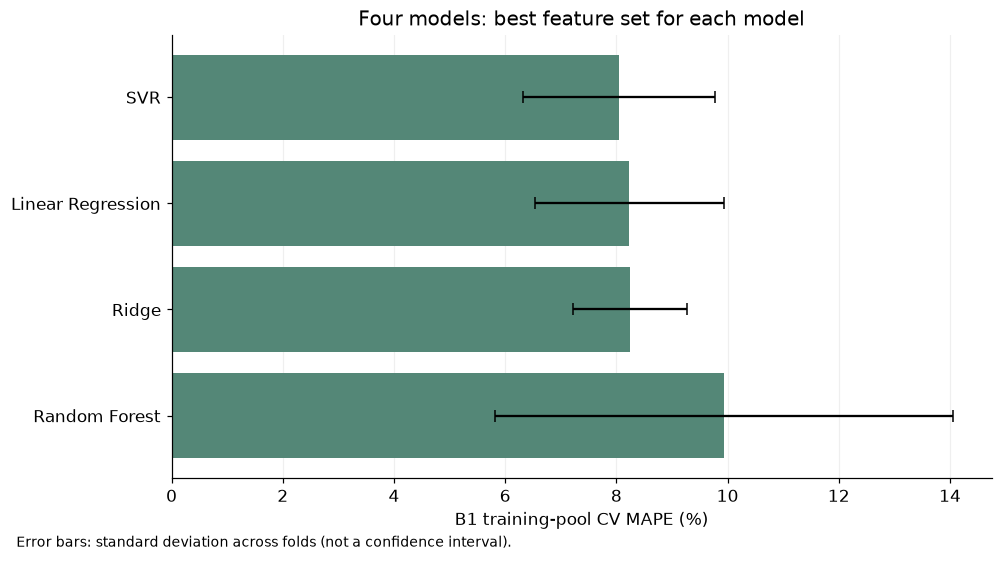

In [7]:
figure = plot_cv_comparison(comparison)
figure.savefig(OUTPUT_DIR / "01_cv_comparison.png", dpi=160, bbox_inches="tight")
plt.show()

### 보조 확인. Random Forest의 짧은 수명 과대 예측
B1 CV가 가장 좋은 Random Forest의 교차검증 예측을 확인합니다.
각 fold의 학습 수명 최솟값보다 짧은 검증 셀을 길게 예측하는지 점검합니다.

B1에는 500사이클 미만 셀이 없어 해당 구간을 직접 검증한 결과는 아닙니다.
이 보조 점검으로 최종 모델을 다시 선택하지 않습니다.

In [8]:
rf_row = comparison.loc[comparison["model"].eq("Random Forest")].sort_values("cv_mape_pct").iloc[0]
rf_choice = {
    **rf_row.to_dict(),
    "feature_columns": FEATURE_SETS[rf_row["feature_set"]],
    "pipeline": searches[rf_row["experiment_id"]].best_estimator_,
}
rf_cv_predictions, rf_fold_scores = cross_validation_predictions(rf_choice, train, splits["cv_splits"])
rf_below = rf_cv_predictions.loc[rf_cv_predictions["below_training_life_range"]]
print(f"Random Forest / {rf_row['feature_set']} — B1 CV MAPE {rf_fold_scores['mape_pct'].mean():.2f}%")
if len(rf_below):
    display(rf_below[["cell_id", "fold", "actual_cycles", "predicted_cycles", "error_cycles", "ape_pct"]])
    print(f"각 fold의 학습 수명 최솟값보다 짧은 검증 셀 {len(rf_below)}개 중 "
          f"{int(rf_below['error_cycles'].gt(0).sum())}개를 과대 예측했습니다. "
          f"평균 오차는 {rf_below['error_cycles'].mean():+.1f}사이클입니다.")
else:
    print("각 fold의 학습 수명 최솟값보다 짧은 검증 셀이 없어 이 방향의 오차를 확인할 수 없습니다.")
print("이 결과는 B1 OOF 보조 점검이며, B2에서 Random Forest의 성능을 측정한 결과는 아닙니다.")

Random Forest / F2_Capacity_Charge_median — B1 CV MAPE 9.94%


,cell_id,fold,actual_cycles,predicted_cycles,error_cycles,ape_pct
25,b1c20,5,534.000,682.200,148.200,27.753
26,b1c21,5,559.000,682.200,123.200,22.039


각 fold의 학습 수명 최솟값보다 짧은 검증 셀 2개 중 2개를 과대 예측했습니다. 평균 오차는 +135.7사이클입니다.
이 결과는 B1 OOF 보조 점검이며, B2에서 Random Forest의 성능을 측정한 결과는 아닙니다.


## 6. 설정 고정 후 hold-out 평가
`selected_config.json`에 모델·특성·설정과 분할 정보를 먼저 저장합니다.
이후 hold-out이나 B2 결과가 나빠도 이 실행에서 후보·규칙을 다시 고르지 않습니다.
선택된 설정으로 CV 예측을 다시 모아 fold별 MAPE와 MAE를 기록하고, 학습 부분으로 적합한 모델의 hold-out 예측을 확인합니다.

In [9]:
freeze_choice(choice, splits, OUTPUT_DIR)
assert (OUTPUT_DIR / "selected_config.json").is_file()
cv_predictions, fold_scores = cross_validation_predictions(choice, train, splits["cv_splits"])
valid_predictions = evaluate_predictions(
    choice["pipeline"], valid, choice["feature_columns"], train, "Valid (Batch 1 Hold-out)"
)
display(fold_scores)
display(pd.DataFrame([metrics(valid_predictions)], index=["Valid (Batch 1 Hold-out)"]))

,fold,n,mape_pct,mae_cycles,mean_error_cycles,nonpositive_predictions
0,1,6,6.720,55.959,-51.815,0
1,2,6,8.595,63.864,26.184,0
2,3,6,6.149,53.624,-14.979,0
3,4,6,11.049,102.361,-73.823,0
4,5,5,7.712,53.462,24.675,0


,n,mape_pct,mae_cycles,mean_error_cycles,nonpositive_predictions
Valid (Batch 1 Hold-out),7,10.551,93.890,-54.447,0


## 7. Batch 1 전체 재학습 → Batch 2 평가
선택된 설정 그대로 B1 분석군 전체를 학습한 뒤, 여기서 처음 B2를 불러와 평가합니다.
B2는 **양의 유효 수명 라벨이 있는 모든 셀**을 사용하며 큰 오차를 이유로 셀을 제외하지 않습니다.

B2 파일은 `2018-02-20`입니다. 원논문과 파일·분할·분석군이 달라 9.1%를 동일 조건의 재현 기준으로 보기 어렵습니다.
사전 EDA에서 이미 B2·B3의 분포와 상관을 보았으므로 B2는 완전히 미확인인 독립 시험이 아닌 **외부 배치 평가**입니다.

In [10]:
final_model = refit_final_model(choice, b1, OUTPUT_DIR)
raw_b2 = load_feature_table(DATA_DIR, ("Batch 2",))
b2 = raw_b2.loc[np.isfinite(raw_b2["cycle_life"]) & raw_b2["cycle_life"].gt(0)].copy()
print(f"B2 원본 {len(raw_b2)}개 → 유효 수명 {len(b2)}개; 정답 미확인 {len(raw_b2) - len(b2)}개 제외")
print(f"수명 {b2['cycle_life'].min():.0f}~{b2['cycle_life'].max():.0f}사이클")
print(f"100분 초과 충전 기록을 유지한 셀: {int(b2['chargetime_gt100_n'].gt(0).sum())}개")
test_predictions = evaluate_predictions(
    final_model, b2, choice["feature_columns"], b1, "Test (Batch 2)"
)

B2 원본 47개 → 유효 수명 39개; 정답 미확인 8개 제외
수명 392~1186사이클
100분 초과 충전 기록을 유지한 셀: 10개


## 8. 성능표와 Gap
성능은 MAPE(%), Gap은 두 MAPE의 차이인 **퍼센트포인트(%p)**입니다.
`Train−Valid`, `Valid−Test`, `9.1−Test` 순서로 계산하며, 음수이면 뒤쪽 오차가 더 큽니다.
표본 수, 정책·수명 분포와 라벨 정의가 달라 Gap만으로 과적합을 단정하지 않습니다.

In [11]:
performance = performance_table(fold_scores, valid_predictions, test_predictions)
display(performance)

,구분,MAPE (%),비고
0,Train (Batch 1 CV),8.045,B1 학습 부분 5-fold MAPE 산술평균; 튜닝에 사용한 점수
1,Valid (Batch 1 Hold-out),10.551,정책·셀 분리 n=7; MAE=93.89사이클
2,Test (Batch 2),27.383,B1 전체 재학습 후 n=39; MAE=137.05사이클
3,Gap (Train-Valid),-2.506,단위 %p; CV - hold-out. 음수이면 뒤쪽 MAPE가 큼
4,Gap (Valid-Test),-16.833,단위 %p; hold-out - B2. 학습 표본 수·분포도 다르므로 과적합 단정 불가
5,Gap (Target-Test),-18.283,단위 %p; 9.1 - B2. 음수이면 논문 참고값보다 오차가 큼


### 그림 2. 실제 수명과 예측 수명은 얼마나 가까운가?
대각선은 실제값과 예측값이 같은 위치입니다. 위쪽은 과대 예측, 아래쪽은 과소 예측입니다.
hold-out은 B1 학습 부분으로, B2는 B1 분석군 전체로 학습한 모델로 평가했습니다.

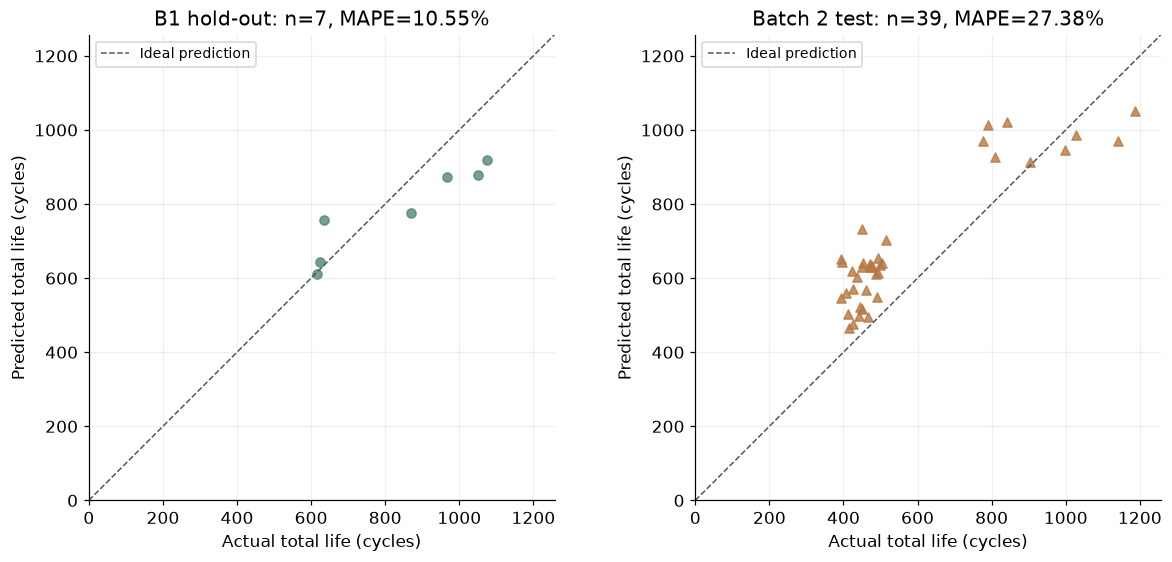

In [12]:
figure = plot_predictions(valid_predictions, test_predictions)
figure.savefig(OUTPUT_DIR / "02_actual_vs_predicted.png", dpi=160, bbox_inches="tight")
plt.show()

## 9. 오차가 큰 셀과 배치 차이 확인
오차는 `예측−실제`로 정의합니다. 양수면 수명을 길게 예측했다는 뜻입니다.
수명 구간별 오차, B1 입력 특성 범위 밖 여부, 상대오차가 큰 5개 셀을 함께 봅니다.
범위 밖 표시는 선택된 특성 중 하나라도 B1 최솟값·최댓값을 벗어난 경우이며, 원인 판정이나 오류 삭제 기준이 아닙니다.

In [13]:
life_band_errors = error_by_life_band(test_predictions)
display(life_band_errors)
error_columns = ["cell_id", "policy_group", "actual_cycles", "predicted_cycles",
                 "error_cycles", "ape_pct", "outside_training_feature_range", "nonpositive_prediction"]
top_errors = test_predictions.nlargest(5, "ape_pct")[error_columns]
display(top_errors)

,life_band,n,mape_pct,mae_cycles,mean_error_cycles,nonpositive_predictions
0,Short (<500),28,31.357,139.063,139.063,0
1,Middle (500-1000),8,19.903,137.555,124.735,0
2,Long (>1000),3,10.238,116.884,-116.884,0


,cell_id,policy_group,actual_cycles,predicted_cycles,error_cycles,ape_pct,outside_training_feature_range,nonpositive_prediction
6,b2c6,3.6C(9%)-5C,393.000,651.033,258.033,65.657,False,False
18,b2c18,5.2C(50%)-4.25C,449.000,733.663,284.663,63.399,False,False
15,b2c15,3.6C(9%)-5C,396.000,644.704,248.704,62.804,False,False
2,b2c2,5.2C(50%)-4.25C,424.000,619.224,195.224,46.043,False,False
27,b2c29,5.2C(58%)-4C,452.000,641.039,189.039,41.823,False,False


### 그림 3. 짧은 수명을 길게 예측하는가?
왼쪽은 실제 수명에 따른 부호 있는 오차, 오른쪽은 상대오차가 큰 5개 셀을 보여 줍니다. B1보다 짧은 수명의 셀이 많은 B2에서
입력·정답 분포 차이가 오차에 영향을 줄 수 있습니다. Random Forest는 학습 정답 범위 밖으로 외삽하기 어려우므로
짧은 수명의 과대 예측을 특히 주의해서 봅니다. 아래 그림은 최종 선택 모델에 대한 결과입니다.

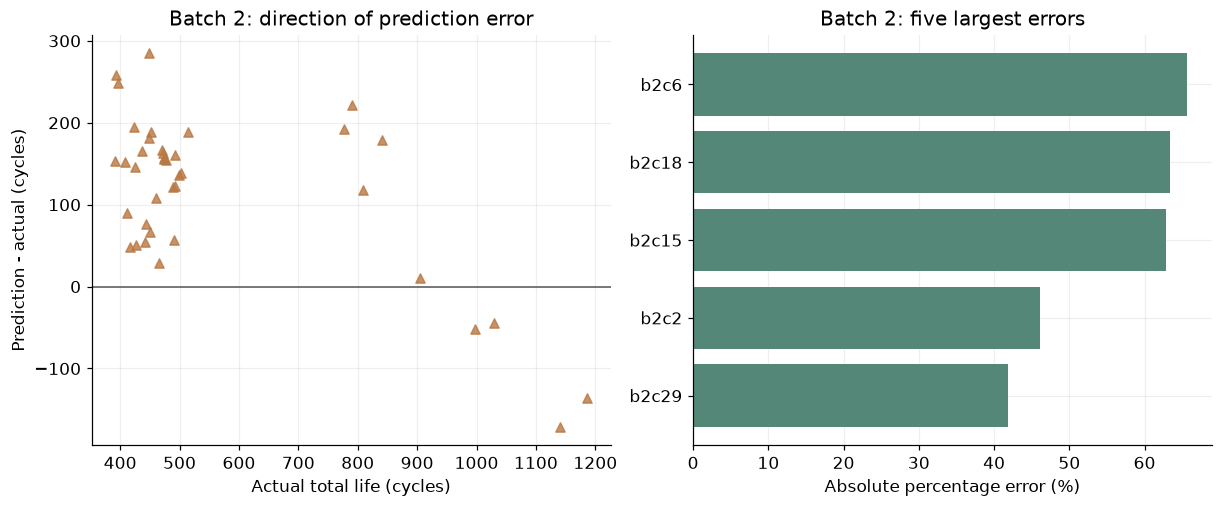

In [14]:
figure = plot_error_analysis(test_predictions)
figure.savefig(OUTPUT_DIR / "03_batch2_error_analysis.png", dpi=160, bbox_inches="tight")
plt.show()

## 10. 실행 결과 요약과 저장
앞에서 계산한 성능표와 예측값으로 핵심 결과를 정리합니다.
요약과 README는 같은 내용을 사용하며, 자세한 셀별 결과는 CSV로 저장합니다.
Train은 각 CV 검증 fold의 MAPE를 단순평균한 값입니다.

In [15]:
# 앞에서 계산한 성능표를 요약과 README에 함께 사용합니다.
table_lines = ["| 구분 | MAPE (%) | 비고 |", "|---|---:|---|"]
for _, row in performance.iterrows():
    value = f"{row['MAPE (%)']:+.2f}" if row['구분'].startswith("Gap") else f"{row['MAPE (%)']:.2f}"
    note = row["비고"]
    if row["구분"].startswith("Train"):
        note += f"; MAE={fold_scores['mae_cycles'].mean():.2f}사이클"
    table_lines.append(f"| {row['구분']} | {value} | {note} |")

test_score = metrics(test_predictions)
test_mape = test_score["mape_pct"]
paper_difference = test_mape - PAPER_TARGET_MAPE
comparison_word = "높습니다" if paper_difference > 0 else "낮습니다"
paper_note = (f"B2 MAPE는 논문 참고값 {PAPER_TARGET_MAPE:g}%보다 {abs(paper_difference):.2f}%p {comparison_word}."
              if paper_difference != 0 else f"B2 MAPE는 논문 참고값 {PAPER_TARGET_MAPE:g}%와 같습니다.")
worst = test_predictions.nlargest(5, "ape_pct")
short_500 = test_predictions.loc[test_predictions["actual_cycles"].lt(500)]
short_note = (f"500사이클 미만 {len(short_500)}개 중 {int(short_500['error_cycles'].gt(0).sum())}개를 길게 예측했습니다. "
              f"평균 오차는 {short_500['error_cycles'].mean():+.1f}사이클입니다."
              if len(short_500) else "이번 평가에는 500사이클 미만 셀이 없습니다.")
settings = ", ".join(f"{key.replace('model__', '')}={value}" for key, value in choice["parameters"].items()) or "기본 설정"

readme_blocks = {
    "MODEL_RESULT": f'''- 최종 모델은 **{choice["model"]}**, Feature는 `{choice["feature_set"]}`입니다.
- 입력 {len(choice["feature_columns"])}개: {", ".join(f"`{name}`" for name in choice["feature_columns"])}
- 최저 CV MAPE와 {choice["tolerance_pp"]:g}%p 이내인 후보 중 Feature가 적은 구성을 우선하고, 다음으로 CV MAPE를 비교했습니다.
- 최종 설정: `{settings}`
- B1 {len(b1)}개 중 학습/CV는 {len(train)}개, hold-out은 {len(valid)}개이며 B2 평가 대상은 {len(b2)}개입니다.''',
    "PERFORMANCE_RESULT": "\n".join(table_lines) + f'''

Gap은 두 MAPE의 차이(%p)이며, 음수이면 뒤쪽 오차가 더 큽니다. 표본 수와 분포가 달라 과적합으로 단정하지 않습니다.
{paper_note} 데이터와 평가 조건이 달라 논문과 직접적인 성능 비교는 어렵습니다.''',
    "ERROR_ANALYSIS": f'''- 상대오차가 큰 셀은 **{", ".join(worst["cell_id"])}**입니다. 이 중 {int(worst["error_cycles"].gt(0).sum())}개를 길게 예측했습니다.
- 위 셀 중 입력 Feature가 B1 범위 밖인 셀은 {int(worst["outside_training_feature_range"].sum())}개입니다. 입력 범위만으로 오차 원인을 확정하기는 어렵습니다.
- {short_note} B1 학습군의 최단 수명은 {b1["cycle_life"].min():.0f}사이클입니다.
- B2 평균 오차(예측−실제)는 {test_score["mean_error_cycles"]:+.1f}사이클입니다. 0 이하 예측은 {test_score["nonpositive_predictions"]}개이며, 예측값을 보정하거나 제외하지 않았습니다.
- 짧은 수명의 학습 표본 부족과 배치별 특성·수명 라벨 차이가 가능한 원인입니다.
- 다음에는 짧은 수명의 학습 데이터를 보완하고, 라벨·처리 기준을 정한 뒤 새로운 외부 데이터로 평가할 예정입니다. 이번 B2 결과로 모델을 다시 선택하지 않습니다.''',
    "ESS_INTERPRETATION": '''- 점검할 셀의 우선순위와 교체 계획을 검토하는 데 활용할 수 있습니다. 다만 짧은 수명을 길게 예측하면 교체가 늦어질 수 있습니다.
- 예측 대상은 **총 cycle_life**이며, 실시간 잔여 수명이나 안전 이상 발생 확률은 아닙니다.
- 실제 적용에는 온도·부하·충전 조건, 시간 경과와 팩 단위의 추가 검증이 필요합니다. BMS의 용량·온도·저항 정보와 예측 불확실성을 함께 확인해야 합니다.''',
}
summary = "\n\n".join([
    "### 이번 실행 결과\n" + readme_blocks["MODEL_RESULT"],
    readme_blocks["PERFORMANCE_RESULT"],
    "### 오류 분석과 개선 방향\n" + readme_blocks["ERROR_ANALYSIS"],
    "### ESS 운영 관점에서의 해석\n" + readme_blocks["ESS_INTERPRETATION"],
    "**분석의 한계:** 마지막 용량으로 B1 분석군을 골라 선택 편향이 남아 있습니다. "
    "B1·B3는 기록 길이+1, B2는 0.88 Ah 미만 도달 시점을 수명으로 제공해 라벨 정의가 다릅니다. "
    "B2도 사전 EDA에서 확인했으므로 완전히 미확인인 독립 시험은 아닙니다.",
])
display(Markdown(summary))

### 이번 실행 결과
- 최종 모델은 **SVR**, Feature는 `F1_DeltaQ`입니다.
- 입력 1개: `dq_log10_variance`
- 최저 CV MAPE와 1%p 이내인 후보 중 Feature가 적은 구성을 우선하고, 다음으로 CV MAPE를 비교했습니다.
- 최종 설정: `C=1000.0, epsilon=10.0, gamma=0.01`
- B1 36개 중 학습/CV는 29개, hold-out은 7개이며 B2 평가 대상은 39개입니다.

| 구분 | MAPE (%) | 비고 |
|---|---:|---|
| Train (Batch 1 CV) | 8.05 | B1 학습 부분 5-fold MAPE 산술평균; 튜닝에 사용한 점수; MAE=65.85사이클 |
| Valid (Batch 1 Hold-out) | 10.55 | 정책·셀 분리 n=7; MAE=93.89사이클 |
| Test (Batch 2) | 27.38 | B1 전체 재학습 후 n=39; MAE=137.05사이클 |
| Gap (Train-Valid) | -2.51 | 단위 %p; CV - hold-out. 음수이면 뒤쪽 MAPE가 큼 |
| Gap (Valid-Test) | -16.83 | 단위 %p; hold-out - B2. 학습 표본 수·분포도 다르므로 과적합 단정 불가 |
| Gap (Target-Test) | -18.28 | 단위 %p; 9.1 - B2. 음수이면 논문 참고값보다 오차가 큼 |

Gap은 두 MAPE의 차이(%p)이며, 음수이면 뒤쪽 오차가 더 큽니다. 표본 수와 분포가 달라 과적합으로 단정하지 않습니다.
B2 MAPE는 논문 참고값 9.1%보다 18.28%p 높습니다. 데이터와 평가 조건이 달라 논문과 직접적인 성능 비교는 어렵습니다.

### 오류 분석과 개선 방향
- 상대오차가 큰 셀은 **b2c6, b2c18, b2c15, b2c2, b2c29**입니다. 이 중 5개를 길게 예측했습니다.
- 위 셀 중 입력 Feature가 B1 범위 밖인 셀은 0개입니다. 입력 범위만으로 오차 원인을 확정하기는 어렵습니다.
- 500사이클 미만 28개 중 28개를 길게 예측했습니다. 평균 오차는 +139.1사이클입니다. B1 학습군의 최단 수명은 534사이클입니다.
- B2 평균 오차(예측−실제)는 +116.4사이클입니다. 0 이하 예측은 0개이며, 예측값을 보정하거나 제외하지 않았습니다.
- 짧은 수명의 학습 표본 부족과 배치별 특성·수명 라벨 차이가 가능한 원인입니다.
- 다음에는 짧은 수명의 학습 데이터를 보완하고, 라벨·처리 기준을 정한 뒤 새로운 외부 데이터로 평가할 예정입니다. 이번 B2 결과로 모델을 다시 선택하지 않습니다.

### ESS 운영 관점에서의 해석
- 점검할 셀의 우선순위와 교체 계획을 검토하는 데 활용할 수 있습니다. 다만 짧은 수명을 길게 예측하면 교체가 늦어질 수 있습니다.
- 예측 대상은 **총 cycle_life**이며, 실시간 잔여 수명이나 안전 이상 발생 확률은 아닙니다.
- 실제 적용에는 온도·부하·충전 조건, 시간 경과와 팩 단위의 추가 검증이 필요합니다. BMS의 용량·온도·저항 정보와 예측 불확실성을 함께 확인해야 합니다.

**분석의 한계:** 마지막 용량으로 B1 분석군을 골라 선택 편향이 남아 있습니다. B1·B3는 기록 길이+1, B2는 0.88 Ah 미만 도달 시점을 수명으로 제공해 라벨 정의가 다릅니다. B2도 사전 EDA에서 확인했으므로 완전히 미확인인 독립 시험은 아닙니다.

In [16]:
# 전체 감사값은 저장하고, 화면에는 필요한 표만 보여 줍니다.
outputs = {
    "batch1_feature_audit.csv": raw_b1,
    "batch2_feature_audit.csv": raw_b2,
    "batch1_cohort_audit.csv": cohort_audit,
    "split_assignments.csv": splits["split_table"],
    "cv_fold_summary.csv": splits["fold_table"],
    "model_comparison.csv": comparison,
    "selected_model_feature_changes.csv": feature_changes,
    "selected_cv_fold_scores.csv": fold_scores,
    "cv_predictions.csv": cv_predictions,
    "random_forest_cv_predictions.csv": rf_cv_predictions,
    "random_forest_cv_fold_scores.csv": rf_fold_scores,
    "holdout_predictions.csv": valid_predictions,
    "batch2_predictions.csv": test_predictions,
    "performance.csv": performance,
    "batch2_error_by_life_band.csv": life_band_errors,
    "batch2_top_errors.csv": top_errors,
}
for filename, table in outputs.items():
    table.to_csv(OUTPUT_DIR / filename, index=False, encoding="utf-8-sig")
(OUTPUT_DIR / "run_summary.md").write_text(summary, encoding="utf-8")

# README의 목차는 유지하고 실행 결과가 들어가는 네 영역만 갱신합니다.
readme_path = Path("README.md")
if readme_path.is_file():
    readme_text = readme_path.read_text(encoding="utf-8")
    for section, body in readme_blocks.items():
        start_marker = f"<!-- {section}_START -->"
        end_marker = f"<!-- {section}_END -->"
        if readme_text.count(start_marker) != 1 or readme_text.count(end_marker) != 1:
            raise ValueError(f"README 자동 갱신 구역을 확인하세요: {section}")
        before, rest = readme_text.split(start_marker, 1)
        _, after = rest.split(end_marker, 1)
        readme_text = before + start_marker + "\n\n" + body + "\n\n" + end_marker + after
    readme_path.write_text(readme_text, encoding="utf-8")
print(f"결과 저장 완료: {len(outputs)}개 CSV 및 요약·설정·모델·그림")

결과 저장 완료: 16개 CSV 및 요약·설정·모델·그림


## 선택: Batch 3 추가 평가
필요할 때만 맨 위의 `EVALUATE_BATCH3=True`로 바꿉니다. B1에서 고정한 모델을 그대로 사용하고
B3 결과로 모델을 다시 선택하지 않습니다. Batch 3 역시 제공 수명과 EOL의 차이, 사전 EDA를 고려합니다.
실행 시 기존 6개 성능 행에 B3 MAPE와 B2−B3·9.1−B3 Gap을 추가한 표도 저장합니다.

In [17]:
if EVALUATE_BATCH3:
    raw_b3 = load_feature_table(DATA_DIR, ("Batch 3",))
    b3 = raw_b3.loc[np.isfinite(raw_b3["cycle_life"]) & raw_b3["cycle_life"].gt(0)].copy()
    batch3_predictions = evaluate_predictions(
        final_model, b3, choice["feature_columns"], b1, "Optional (Batch 3)"
    )
    batch3_score = metrics(batch3_predictions)
    batch3_performance = pd.concat([
        performance,
        pd.DataFrame([
            {"구분": "Test (Batch 3)", "MAPE (%)": batch3_score["mape_pct"],
             "비고": f"고정 모델 추가 평가 n={len(b3)}; MAE={batch3_score['mae_cycles']:.2f}사이클"},
            {"구분": "Gap (Batch2-Batch3)", "MAPE (%)": test_mape - batch3_score["mape_pct"],
             "비고": "단위 %p; B2 - B3. 음수이면 B3 오차가 더 큼"},
            {"구분": "Gap (Target-Test, Batch 3)", "MAPE (%)": PAPER_TARGET_MAPE - batch3_score["mape_pct"],
             "비고": "단위 %p; 9.1 - B3. 9.1은 논문 참고값이며 B3의 논문 재현 성능은 아님"},
        ]),
    ], ignore_index=True)
    display(batch3_performance)
    batch3_performance.to_csv(OUTPUT_DIR / "batch3_performance.csv", index=False, encoding="utf-8-sig")
    raw_b3.to_csv(OUTPUT_DIR / "batch3_feature_audit.csv", index=False, encoding="utf-8-sig")
    batch3_predictions.to_csv(OUTPUT_DIR / "batch3_predictions.csv", index=False, encoding="utf-8-sig")
else:
    print("Batch 3는 실행하지 않았습니다. 기본 성능표는 Batch 1 / Batch 2 기준입니다.")

Batch 3는 실행하지 않았습니다. 기본 성능표는 Batch 1 / Batch 2 기준입니다.


## 다음 확인
- 논문: Severson et al. (2019), [Data-driven prediction of battery cycle life before capacity degradation](https://www.nature.com/articles/s41560-019-0356-8)

이번 결과는 제공된 셀과 충전 조건에서 확인한 성능입니다.
다음에는 수명 라벨 기준을 맞춘 추가 데이터와 다른 온도·부하 조건에서 모델 검증이 필요할 것 같습니다.